In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd

In [2]:
# ГДС
G = ox.load_graphml(r'tests\data\test_rng.ml')
G = ox.project_graph(G)
print(G.number_of_nodes(), G.number_of_edges())

5514 12199


In [3]:
buildings = gpd.read_file(r'tests\data\buildings.gpkg')
buildings = ox.projection.project_gdf(buildings)
buildings.head(2)

c:\Users\obsid\.conda\envs\ox2\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'buildings.gpkg': 'buildings' (default), 'здания'. Specify layer parameter to avoid this warning.
  result = read_func(


,osmid,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,geometry
0,114435873,None,None,apartments,улица Ленинского Комсомола,2,9,None,"POLYGON ((521283.901 6220143.312, 521291.376 6..."
1,114435874,None,None,store,улица Ленинского Комсомола,None,None,None,"POLYGON ((521066.656 6219874.938, 521059.407 6..."


In [4]:
g_nodes = ox.graph_to_gdfs(G, edges=False)

buildings = buildings.sjoin_nearest(g_nodes[['geometry']], how='left')
buildings.rename(columns={'osmid_right':'node'}, inplace=True)
buildings.head(2)

,osmid_left,name,amenity,building,addr:street,addr:housenumber,building:levels,building:flats,geometry,node
0,114435873,None,None,apartments,улица Ленинского Комсомола,2,9,None,"POLYGON ((521283.901 6220143.312, 521291.376 6...",9085465306
0,114435873,None,None,apartments,улица Ленинского Комсомола,2,9,None,"POLYGON ((521283.901 6220143.312, 521291.376 6...",9085465307


In [5]:
buildings_s = buildings.sample(500)

<Axes: >

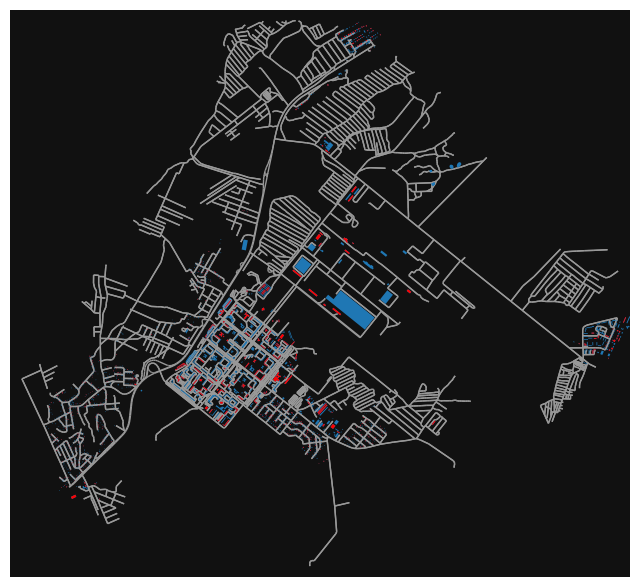

In [6]:
fig, ax = ox.plot_graph(G, node_size=0, show=False, close=False)
buildings.plot(ax=ax)
buildings_s.plot(ax=ax, color='red')

# Предварительно

In [7]:
from genesis.core import BestPointsBase, LSCPBase, MCLPBase, MetricBase, StateBase


class Boosting(MCLPBase):
    '''
    Реализация базового алгоритма MCLP как гибрида

    Является функцией гибридизации алгоритмов BestPoints, MCLP и LSCP,
    методом бустинга, т.е. последовательного выполнения функций и передачи полученного 
    результата далее.
    '''
    def __init__(self,
                 functions: list,
                 state_function:  StateBase      = None,
                 metric_function: MetricBase     = None,
                 function_end_function: callable =None,
                 **kwargs):

        # 0. Проверка корректности пришедших данных
        if not isinstance(functions, list):
            raise TypeError('Аргумент `functions` должен быть типа list!')
        # if not isinstance(function_end_function, callable) and not function_end_function is None:
        #     raise TypeError('Аргумент `function_end_function` должен быть типа callable или иметь значение None!')
        if not isinstance(state_function, StateBase) and not state_function is None:
            raise TypeError('Аргумент `state_function` должен быть типа StateBase или иметь значение None!')
        if not isinstance(metric_function, MetricBase) and not metric_function is None:
            raise TypeError('Аргумент `metric_function` должен быть типа MetricBase или иметь значение None!')

        # 1. Сохранение данных в свойствах функции
        self.functions = functions
        self.function_end_function = function_end_function
        super().__init__(state_function, metric_function, **kwargs)

    
    def __call__(self,
                 env:nx.Graph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        ## Аргументы

        `env`:nx.Graph

            Граф улично-дорожной сети

        `dynamic_nodes`: dict

            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.

        `static_nodes`: dict = None

            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.

        `area`: pd.Series = None

            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.

        ## Возвращает

        `best_dynamic_nodes, best_metric`: tuple[list | dict, float]

            Список или словарь лучших мест размещения, значение метрики metric_function
            для лучшего размещения.
        '''
        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.Graph):
            raise TypeError("Тип аргумента `env` должен быть Graph!")
        if not isinstance(dynamic_nodes, dict) and not dynamic_nodes is None:
            raise TypeError(f'Аргумент `dynamic_nodes` должен иметь тип `dict`! Имеет {type(area)}')
        if not isinstance(static_nodes, dict) and not static_nodes is None:
            raise TypeError(f'Аргумент `static_nodes` должен иметь тип `dict`! Имеет {type(area)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

        # 1. Сбор данных о размещении в единый словарь
        if not static_nodes is None:
            best_nodes = {**dynamic_nodes, **static_nodes}
        else:
            best_nodes = dynamic_nodes

        # 2. Последовательный перебор всех функций
        i=0
        for m in self.functions:
            best_nodes, metric_val = m(env           = env,
                                       area          = area,
                                       dynamic_nodes = best_nodes,
                                       **kwargs)
            print(i, best_nodes, metric_val)
            i+=1

        # 3. Возвращаем результат
        return best_nodes, metric_val
    
    def append(self, func):
        '''
        Добавить функцию расчета
        '''
        if isinstance(func, (BestPointsBase, MCLPBase, LSCPBase)):
            self.functions.append(func)
        else:
            raise TypeError('Аргумент `func` должен быть типом класса BestPoints, MCLP или LSCP!')

## Для задачи BLP

In [31]:
import numpy as np
from fire_units.metrics import CoverIndexBuilding, CoverIndexValue
from genesis.best_points import BestNodeHillClimbing, BestNodesHalfDiameter
from genesis.hybridisation import AdapterBLP2MCLP
from genesis.lscp import LSCP_ADD
from genesis.metrics import ArrivalTime
from genesis.states import ArrivalTimeMatrixState, FirstArrivalUnitState, get_atm


# matrix = get_atm(G, data=buildings_s, cutoff=5)
# print(matrix.shape)

# Функция - гибридизации
hybrid = Boosting([])

# Основная метрика
metric_demand = CoverIndexBuilding(buildings_s, ip_val=5)



# Реализация BestNodeHillClimbing_HD_Max_Mean
## Добавляем функцию: ADD
hybrid.append(
    AdapterBLP2MCLP(
        BestNodesHalfDiameter()
    )
)
## Добавляем функцию: HC+max
hybrid.append(
    AdapterBLP2MCLP(
        # BestNodeHillClimbing(state_function=ArrivalTimeMatrixState(matrix=matrix), metric_function=ArrivalTime())
        BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime())
    )
)
## Добавляем функцию: HC+mean
hybrid.append(
    AdapterBLP2MCLP(
        # BestNodeHillClimbing(state_function=ArrivalTimeMatrixState(matrix=matrix), metric_function=ArrivalTime(np.max))
        BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTime(f=np.max))
    )
)

# Стартовое размещение
start_nodes = {
    list(g_nodes.index)[0]:'псч-1'
}

# Собственно применение гибрида
best_nodes, best_metric = hybrid(env=G, dynamic_nodes=start_nodes)



0 {4116035731: 'псч-1'} None
1 {426923808: 'псч-1'} 8.355415617070701
2 {4116049991: 'псч-1'} 18.03619171428572


In [ ]:
nodes = ox.graph_to_gdfs(G, edges=False)
nodes['node'] = nodes.index
nodes.head(2)

In [35]:
matrix = get_atm(G, data=nodes)
print(matrix.shape)

BestNodeHillClimbing(state_function=ArrivalTimeMatrixState(matrix=matrix), metric_function=ArrivalTime())(env=G)  #, start_point = )

|########################################| 100.0%
(5514, 5514)


(426923808, np.float64(8.355415617070701))

In [36]:
BestNodeHillClimbing(state_function=ArrivalTimeMatrixState(matrix=matrix), metric_function=ArrivalTime())(env=G)

(426923808, np.float64(8.355415617070701))

In [37]:
BestNodeHillClimbing(state_function=ArrivalTimeMatrixState(matrix=matrix), metric_function=ArrivalTime(np.max))(env=G)

(2034401823, np.float64(18.917574142857156))

# Окончательно

In [6]:
from genesis.core import BestPointsBase, LSCPBase, MCLPBase, MetricBase, StateBase


class Hybridization(MCLPBase):
    '''
    Реализация базового алгоритма MCLP как гибрида

    Является функцией гибридизации алгоритмов BestPoints, MCLP и LSCP,
    методами бустинга и беггинга, т.е. последовательного выполнения функций и передачи полученного 
    результата далее.
    '''
    def __init__(self,
                 state_function:        StateBase,
                 metric_function:       MetricBase,
                 functions:             list,
                 type_of_hybrid:        str        = 'Boosting',
                 function_end_function: callable   = None,
                 **kwargs):
        '''
        ## Аргументы

        `functions`: list
            Список функций для гибридизации.

        `type_of_hybrid`: str = 'Boosting'  
            Тип гибридизации. Возможные варианты: 'Boosting' или 'Stacking'.
            * 'Boosting' - метод бустинга, т.е. последовательного выполнения функций и передачи полученного 
            результата далее.
            * 'Stacking' - метод стекинга, т.е. параллельного выполнения функций и выбора лучшего результата.  

        `state_function`: StateBase = None
            Функция для расчета состояния.

        `metric_function`: MetricBase = None
            Функция для расчета основной метрики.

        `function_end_function`: callable = None
            Функция для выполнения после выполнения каждой функции.

        `**kwargs`
            Дополнительные аргументы для функций.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(functions, list):
            raise TypeError('Аргумент `functions` должен быть типа list!')
        if not callable(function_end_function) and function_end_function is not None:
            raise TypeError('Аргумент `function_end_function` должен быть типа callable или иметь значение None!')
        if not isinstance(state_function, StateBase) and not state_function is None:
            raise TypeError('Аргумент `state_function` должен быть типа StateBase или иметь значение None!')
        if not isinstance(metric_function, MetricBase) and not metric_function is None:
            raise TypeError('Аргумент `metric_function` должен быть типа MetricBase или иметь значение None!')
        if type_of_hybrid not in ['Boosting', 'Stacking']:
            raise ValueError('Аргумент `type_of_hybrid` должен быть типа str и иметь значение "Boosting" или "Stacking"!')

        # 1. Сохранение данных в свойствах функции
        self.functions             = functions
        self.type_of_hybrid        = type_of_hybrid
        self.function_end_function = function_end_function
        super().__init__(state_function, metric_function, **kwargs)


    def append(self, func):
        '''
        Добавить функцию расчета
        '''
        if isinstance(func, (BestPointsBase, MCLPBase, LSCPBase)):
            self.functions.append(func)
        else:
            raise TypeError('Аргумент `func` должен быть типом класса BestPoints, MCLP или LSCP!')


    def __call__(self,
                 env:           nx.Graph,
                 dynamic_nodes: dict,
                 static_nodes:  dict      = None,
                 area:          pd.Series = None,
                 **kwargs):
        '''
        ## Аргументы

        `env`:nx.Graph

            Граф улично-дорожной сети

        `dynamic_nodes`: dict

            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.

        `static_nodes`: dict = None

            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.

        `area`: pd.Series = None

            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.

        ## Возвращает

        `best_dynamic_nodes, best_metric`: tuple[list | dict, float]

            Список или словарь лучших мест размещения, значение метрики metric_function
            для лучшего размещения.
        '''
        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.Graph):
            raise TypeError("Тип аргумента `env` должен быть Graph!")
        if not isinstance(dynamic_nodes, dict) and not dynamic_nodes is None:
            raise TypeError(f'Аргумент `dynamic_nodes` должен иметь тип `dict`! Имеет {type(area)}')
        if not isinstance(static_nodes, dict) and not static_nodes is None:
            raise TypeError(f'Аргумент `static_nodes` должен иметь тип `dict`! Имеет {type(area)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')


        main_best_metric = None
        main_best_nodes  = None
        best_nodes = dynamic_nodes.copy()

        # 2. Последовательный перебор всех функций
        i = 0
        for m in self.functions:
            if self.type_of_hybrid == 'Boosting':
                best_nodes, cur_metric = m(env       = env,
                                       area          = area,
                                       dynamic_nodes = best_nodes,
                                       static_nodes  = static_nodes,
                                       **kwargs)
            elif self.type_of_hybrid == 'Stacking':
                best_nodes, cur_metric = m(env       = env,
                                       area          = area,
                                       dynamic_nodes = dynamic_nodes.copy(),
                                       static_nodes  = static_nodes,
                                       **kwargs)
            
            # Оценка основной метрики
            # if self.metric_function and self.state_function:
            if not static_nodes is None:
                all_nodes = {**best_nodes, **static_nodes}
            else:
                all_nodes = best_nodes
            # all_nodes  = list_dict_concat(best_nodes, static_nodes)
            times, nearest = self.state_function(env=env, points=all_nodes, **kwargs)
            cur_metric = self.metric_function(times, area=area, **kwargs)

            # Проверяем улучшилась ли основная метрика, если да, то сохраняем результат
            # print('!', main_best_metric, cur_metric)
            if main_best_metric is None:
                main_best_nodes  = best_nodes
                main_best_metric = cur_metric
            elif self.metric_function.compare(main_best_metric, cur_metric) == cur_metric:
                main_best_nodes  = best_nodes
                main_best_metric = cur_metric
            

            # Печать результатов
            if self.function_end_function:
                self.function_end_function(turn = i,
                            best_metric = main_best_metric,
                            cur_metric  = cur_metric,
                            best_nodes  = best_nodes)
            i += 1

        # 3. Возвращаем результат
        return main_best_nodes, main_best_metric

## Для задачи BLP

### Полный (эталон)

ИП-5

In [21]:
import numpy as np
from fire_units.metrics import CoverIndexBuilding
from genesis.best_points import BestNodesFull
from genesis.metrics import ArrivalTime
from genesis.utils import Progressbar

# Основная метрика
metric_demand = CoverIndexBuilding(buildings_s, ip_val=5)

pb = Progressbar(G.number_of_nodes(), bins=40)
best_nodes_full = BestNodesFull(
    state_function=FirstArrivalUnitState(),
    metric_function=metric_demand,
    node_calc_end_function=pb
)

best_node, best_metric = best_nodes_full(env=G)
print(best_node, best_metric)

|########################################| 100.0%
426923822 35.61368209255533


t_ср

In [23]:
import numpy as np
from fire_units.metrics import CoverIndexBuilding
from genesis.best_points import BestNodesFull
from genesis.metrics import ArrivalTime
from genesis.utils import Progressbar

# Основная метрика
metric_demand = ArrivalTime()

pb = Progressbar(G.number_of_nodes(), bins=40)
best_nodes_full = BestNodesFull(
    state_function=FirstArrivalUnitState(),
    metric_function=metric_demand,
    node_calc_end_function=pb
)

best_node, best_metric = best_nodes_full(env=G)
print(best_node, best_metric)

|########################################| 100.0%
426923808 8.355415617070701


### Стекинг (параллельно)

На примере `SHC = HC*10[t_ср]`

In [31]:
import numpy as np
from fire_units.metrics import CoverIndexBuilding
from genesis.tools import list_dict_concat
# from genesis.fire_units.metrics import CoverIndexBuilding, CoverIndexValue
from genesis.best_points import BestNodeHillClimbing, BestNodesHalfDiameter
from genesis.hybridisation import AdapterBLP2MCLP
from genesis.lscp import LSCP_ADD
from genesis.metrics import ArrivalTime
from genesis.states import ArrivalTimeMatrixState, FirstArrivalUnitState, get_atm



# Основная метрика
# metric_demand = CoverIndexBuilding(buildings_s, ip_val=5)
metric_demand = ArrivalTime()

# Функция - гибридизации
hybrid = Hybridization(
    state_function = FirstArrivalUnitState(),
    metric_function = metric_demand,
    functions = [],
    type_of_hybrid = 'Stacking',
    function_end_function = lambda turn, best_metric, cur_metric, best_nodes: print(turn, cur_metric)
)

def node_calc_end_function(best_node, best_metric):
    print(round(best_metric, 2), end='\r')

# Реализация BestNodeShotgunHillClimbing
for i in range(10):
    hybrid.append(
        AdapterBLP2MCLP(
            BestNodeHillClimbing(
                state_function    = FirstArrivalUnitState(), 
                metric_function   = metric_demand,  #ArrivalTime(),
                first_node_random = True,
                node_calc_end_function=node_calc_end_function
                )
        )
    )


# Стартовое размещение
start_nodes = {
    list(g_nodes.index)[0]:'псч-1'
}

# Собственно применение гибрида
best_nodes, best_metric = hybrid(env=G, dynamic_nodes=start_nodes)
print(best_nodes, best_metric)

0 8.58465499518532
1 8.58465499518532
2 8.506199948427117
3 11.133084091219374
4 11.133084091219374
5 8.502387347682204
6 8.355415617070701
7 12.748879805855482
8 8.506199948427117
9 8.58465499518532
{426923808: 'псч-1'} 8.355415617070701


In [32]:
metric_demand = CoverIndexBuilding(buildings, ip_val=5)


for i in range(10):
    nn = [1]
    def node_calc_end_function(best_node, best_metric):
        print('.'*nn[0], round(best_metric, 2), end='\r')
        # print(round(best_metric, 2), end='|')
        nn[0] += 1
        
    bnhc = BestNodeHillClimbing(
        state_function=FirstArrivalUnitState(), 
        metric_function=ArrivalTime(),
        first_node_random = True,
        node_calc_end_function=node_calc_end_function
        )
    best_nodes, best_metric = bnhc(
        env=G, 
        # start_point=start_nodes,
        )
    # print('')
    print(best_nodes, best_metric)

3750525427 12.572120350693002
426923837 8.506199948427117 8.51
426923808 8.35541561707070136
426923808 8.355415617070701........ 8.36
4796070872 12.748879805855482
426923808 8.355415617070701
426923808 8.355415617070701...................................... 8.36
426923835 8.58465499518532
426923808 8.355415617070701.............................................. 8.36
426923837 8.506199948427117


### Бустинг (последовательно)

На примере `HD+HC[t_ср]+HC[ИП-5]`

In [33]:
import numpy as np
from fire_units.metrics import CoverIndexBuilding
from genesis.tools import list_dict_concat
# from genesis.fire_units.metrics import CoverIndexBuilding, CoverIndexValue
from genesis.best_points import BestNodeHillClimbing, BestNodesHalfDiameter
from genesis.hybridisation import AdapterBLP2MCLP
from genesis.lscp import LSCP_ADD
from genesis.metrics import ArrivalTime
from genesis.states import ArrivalTimeMatrixState, FirstArrivalUnitState, get_atm



# Основная метрика
metric_demand = CoverIndexBuilding(buildings_s, ip_val=5)


# Функция - гибридизации
hybrid = Hybridization(
    state_function = FirstArrivalUnitState(),
    metric_function = metric_demand,
    functions = [],
    type_of_hybrid = 'Boosting',
    function_end_function = lambda turn, best_metric, cur_metric, best_nodes: print(turn, cur_metric)
)

nn = [1]
def node_calc_end_function(best_node, best_metric):
    print(round(best_metric, 2), end='\r')
    nn[0] += 1

# Реализация BestNodeShotgunHillClimbing
hybrid.append(
    AdapterBLP2MCLP(
        BestNodesHalfDiameter()
    )
)
hybrid.append(
    AdapterBLP2MCLP(
        BestNodeHillClimbing(
            state_function=FirstArrivalUnitState(), 
            metric_function=ArrivalTime(),
            node_calc_end_function=node_calc_end_function,
            )
    )
)
hybrid.append(
    AdapterBLP2MCLP(
        BestNodeHillClimbing(
            state_function    = FirstArrivalUnitState(), 
            metric_function   = CoverIndexBuilding(buildings_s, ip_val=5),
            node_calc_end_function=node_calc_end_function
            )
    )
)



# Стартовое размещение
start_nodes = {
    list(g_nodes.index)[0]:'псч-1'
}

# Собственно применение гибрида
best_nodes, best_metric = hybrid(env=G, dynamic_nodes=start_nodes)
print(best_nodes, best_metric)

0 3.2193158953722336
1 12.273641851106639
2 20.321931589537222
{6222357764: 'псч-1'} 20.321931589537222
